<a href="https://colab.research.google.com/github/lexiduan-creator/stats507-final-project-Liyuan/blob/main/yelp_bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets scikit-learn matplotlib wordcloud -q

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd


dataset = load_dataset("yelp_review_full", split="train[:5000]")
df = pd.DataFrame(dataset)


print("Shape:", df.shape)
print("\n数据类型:")
print(df.dtypes)
print("\n前3条:")
print(df.head(3))
print("\n每个星级的数量:")
print(df["label"].value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shape: (5000, 2)

数据类型:
label     int64
text     object
dtype: object

前3条:
   label                                               text
0      4  dr. goldberg offers everything i look for in a...
1      1  Unfortunately, the frustration of being Dr. Go...
2      3  Been going to Dr. Goldberg for over 10 years. ...

每个星级的数量:
label
0     883
1    1126
2    1119
3     978
4     894
Name: count, dtype: int64


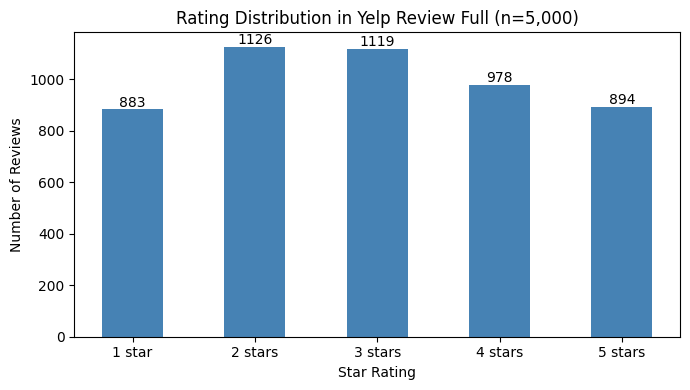

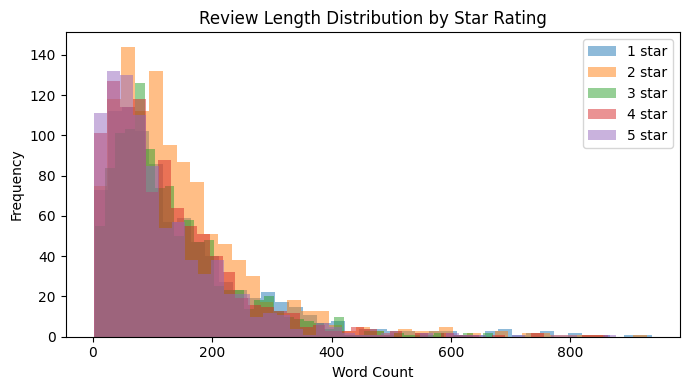

In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Figure 1
star_counts = df["label"].value_counts().sort_index()
labels_name = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels_name, star_counts.values, color="steelblue", width=0.5)
for bar, val in zip(bars, star_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontsize=10)
plt.title("Rating Distribution in Yelp Review Full (n=5,000)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150)
plt.show()

# Figure 2
df["text_length"] = df["text"].apply(lambda x: len(x.split()))
plt.figure(figsize=(7, 4))
for i in range(5):
    subset = df[df["label"] == i]["text_length"]
    plt.hist(subset, bins=40, alpha=0.5, label=f"{i+1} star")
plt.title("Review Length Distribution by Star Rating")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150)
plt.show()

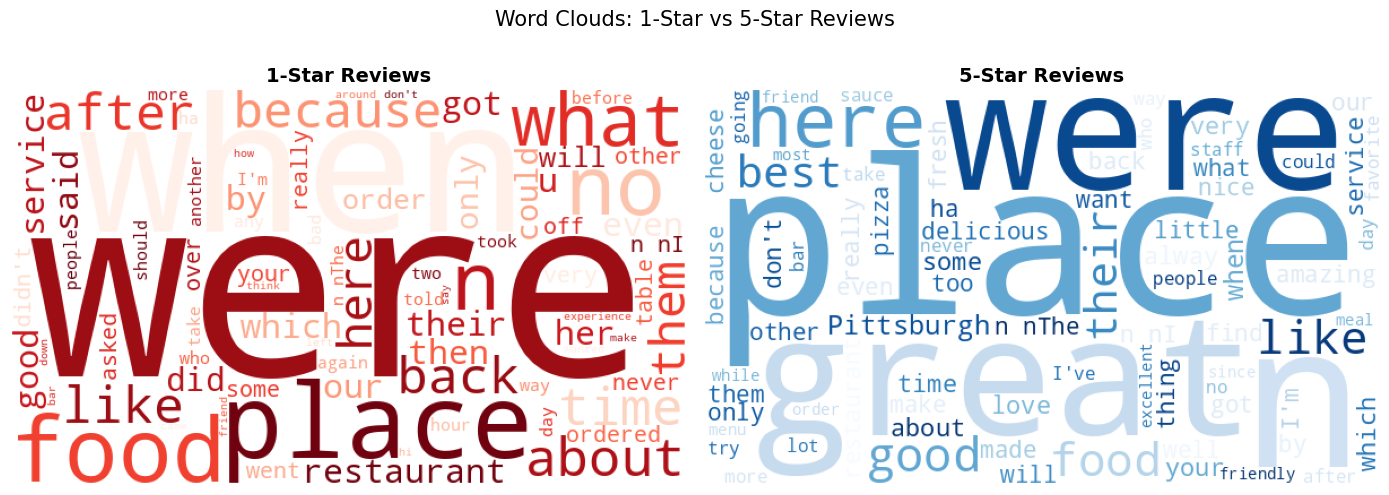

In [4]:
from wordcloud import WordCloud

stopwords = {"the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
             "for", "of", "with", "is", "was", "it", "i", "my", "we", "this",
             "that", "they", "he", "she", "you", "have", "had", "be", "are",
             "not", "so", "as", "up", "out", "if", "do", "just", "get", "go",
             "me", "all", "one", "also", "can", "would", "there", "been", "from"}

texts = df["text"].tolist()
label_list = df["label"].tolist()


star1 = " ".join([texts[i] for i in range(len(texts)) if label_list[i] == 0])
star5 = " ".join([texts[i] for i in range(len(texts)) if label_list[i] == 4])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, title, color in zip(
    axes,
    [star1, star5],
    ["1-Star Reviews", "5-Star Reviews"],
    ["Reds", "Blues"]
):
    wc = WordCloud(width=600, height=350,
                   background_color="white",
                   colormap=color,
                   stopwords=stopwords,
                   max_words=80).generate(text)
    ax.imshow(wc)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold")

plt.suptitle("Word Clouds: 1-Star vs 5-Star Reviews", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from transformers import BertTokenizer, BertForSequenceClassification, get_scheduler
from torch.utils.data import DataLoader, Dataset
import torch
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
import numpy as np


train_data = load_dataset("yelp_review_full", split="train[:8000]")
test_data = load_dataset("yelp_review_full", split="test[:1000]")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class YelpDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.texts = data["text"]
        self.labels = data["label"]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = YelpDataset(train_data, tokenizer)
test_dataset = YelpDataset(test_data, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=5)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 3
scheduler = get_scheduler("linear", optimizer=optimizer,
                           num_warmup_steps=0,
                           num_training_steps=num_epochs * len(train_loader))

# training
train_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("Training complete!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 - Loss: 1.1824
Epoch 2/3 - Loss: 0.8556
Epoch 3/3 - Loss: 0.6470
Training complete!


Test Accuracy: 0.5590

Classification Report:
              precision    recall  f1-score   support

      1 star       0.71      0.66      0.69       189
     2 stars       0.44      0.51      0.47       204
     3 stars       0.53      0.53      0.53       245
     4 stars       0.57      0.51      0.54       215
     5 stars       0.62      0.63      0.62       147

    accuracy                           0.56      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.57      0.56      0.56      1000



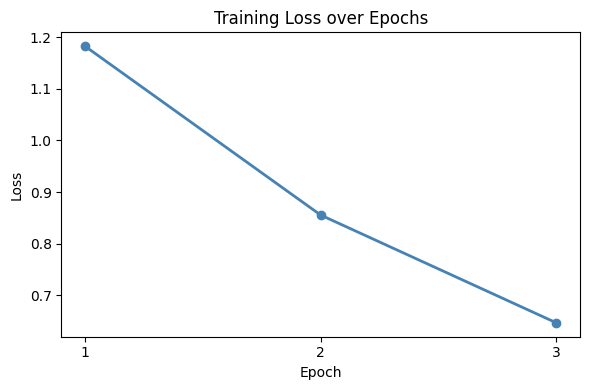

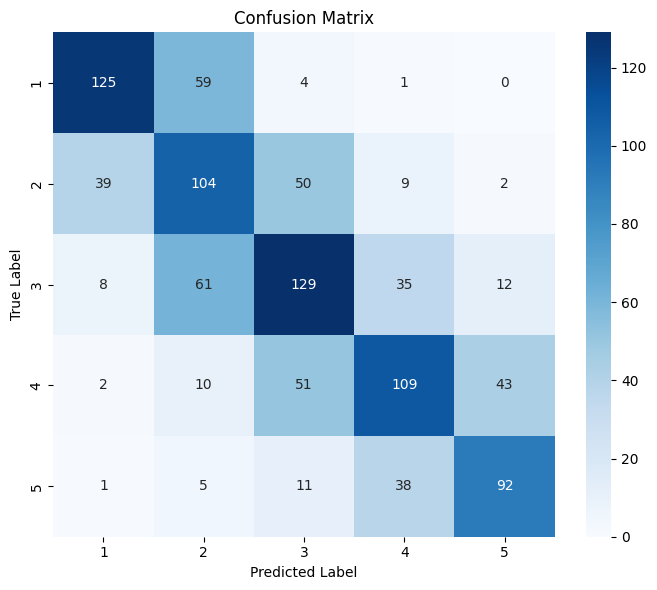

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["1 star","2 stars","3 stars","4 stars","5 stars"]))

# figure 1
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], train_losses, marker="o", color="steelblue", linewidth=2)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks([1, 2, 3])
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

# figure 2
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["1","2","3","4","5"],
            yticklabels=["1","2","3","4","5"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()